Our Lagrangian is

$$\mathcal{L} = \frac{1}{2}\tilde{m}\tilde{L}\left(\tilde{\dot\theta}^2 + \tilde{A}^2\sin^2(\tau)\sin^2(\tilde{\theta})\right) + \tilde{L}\tilde{\dot\theta}^2 \sin^2(\tilde\theta) + \cos(\tilde\theta)(\tilde{m}+ 1).$$

The Euler--Lagrange equation of motion is therefore, on the left side,
$$\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \tilde{\dot\theta}}\right) = \frac{d}{dt}\left(\tilde{m} \tilde{L} \tilde{\dot\theta} + 2\tilde{L} \tilde{\dot\theta}\sin^2(\tilde\theta)\right) = \tilde{m}\tilde{L} \tilde{\ddot\theta} + 4\tilde{L}\tilde{\dot\theta}^2\sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L}\tilde{\ddot\theta}\sin^2(\tilde\theta).$$

On the right side, we have $$\frac{\partial \mathcal{L}}{\partial \tilde \theta} = \tilde{m}\tilde{L} \tilde{A}^2 \sin^2(\tau) \sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L} \tilde{\dot\theta}^2 \sin(\tilde\theta)\cos(\tilde\theta) - \sin(\tilde\theta)(\tilde{m} + 1).$$

So, the E--L equation is $$\tilde{m}\tilde{L} \tilde{\ddot\theta} + 4\tilde{L}\tilde{\dot\theta}^2\sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L}\tilde{\ddot\theta}\sin^2(\tilde\theta) = \tilde{m}\tilde{L} \tilde{A}^2 \sin^2(\tau) \sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L} \tilde{\dot\theta}^2 \sin(\tilde\theta)\cos(\tilde\theta) - \sin(\tilde\theta)(\tilde{m} + 1).$$


We can rewrite this as $$\tilde{\ddot\theta}= \frac{\tilde{m}\tilde{L} \tilde{A}^2 \sin^2(\tau) \sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L} \tilde{\dot\theta}^2 \sin(\tilde\theta)\cos(\tilde\theta) - \sin(\tilde\theta)(\tilde{m} + 1)  - 4\tilde{L}\tilde{\dot\theta}^2\sin(\tilde\theta)\cos(\tilde\theta)}{\tilde{m}\tilde{L}  +  2\tilde{L}\sin^2(\tilde\theta) }$$

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from numpy import sin, cos

We can rewrite this as $$\tilde{\ddot\theta}= \frac{\tilde{m}\tilde{L} \tilde{A}^2 \sin^2(\tau) \sin(\tilde\theta)\cos(\tilde\theta) + 2\tilde{L} \tilde{\dot\theta}^2 \sin(\tilde\theta)\cos(\tilde\theta) - \sin(\tilde\theta)(\tilde{m} + 1)  - 4\tilde{L}\tilde{\dot\theta}^2\sin(\tilde\theta)\cos(\tilde\theta)}{\tilde{m}\tilde{L}  +  2\tilde{L}\sin^2(\tilde\theta) }$$

## We can now define our function

In [2]:
def ELE(tau, X, L, A, m):
    '''
        Equation of motion for system
        return:[ddot theta, dot theta]
     '''
    dtheta, theta = X
    ddtheta = (m * L * A**2 * sin(tau)**2 * sin(theta) * cos(theta) 
               + 2 * L * dtheta**2 * sin(theta) * cos(theta)
               - sin(theta) * (m + 1)
               - 4 * L * dtheta**2 * sin(theta) * cos(theta)
                ) / ( m * L + 2 * L * sin(theta)**2)

    return [ddtheta, dtheta]

In [6]:
def plotIC(thetaZero, dthetaZero, tau_max, L = 1, A = 1, m = 1):
    time = np.linspace(0, tau_max, 1000)
    solution = solve_ivp(ELE, (0, tau_max), (0, np.pi/6), args = (L, A, m), t_eval = time, max_step=1e-2)
    dthetas, thetas = solution.y
    fig, ax = plt.subplots(1,2)
    ax[0].plot(time, thetas)
    ax[0].set_xlabel(r'$\tau$ (dimensionless time)')
    ax[0].set_ylabel(r'$\tilde\theta$ ("dimensionless" angle)')
    ax[1].plot(thetas, dthetas)
    ax[1].set_xlabel(r'$\tilde\theta$')
    ax[1].set_ylabel(r'$\dot{\tilde{\theta}}$')

    fig.suptitle(rf"$\theta$ over time for $\tilde{m} = \tilde{A} = \tilde{L} = 1$ and $\theta(0) = {thetaZero:.2f}, \dot\theta(0) = {dthetaZero:.2f}$")

    fig.savefig('test.png')


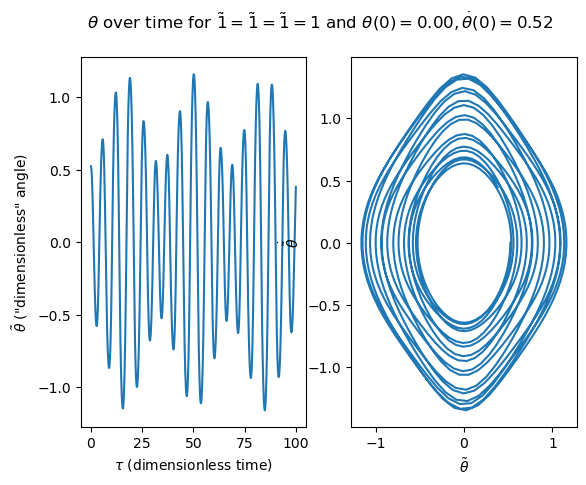

In [7]:
plotIC(0, np.pi/6, 100)

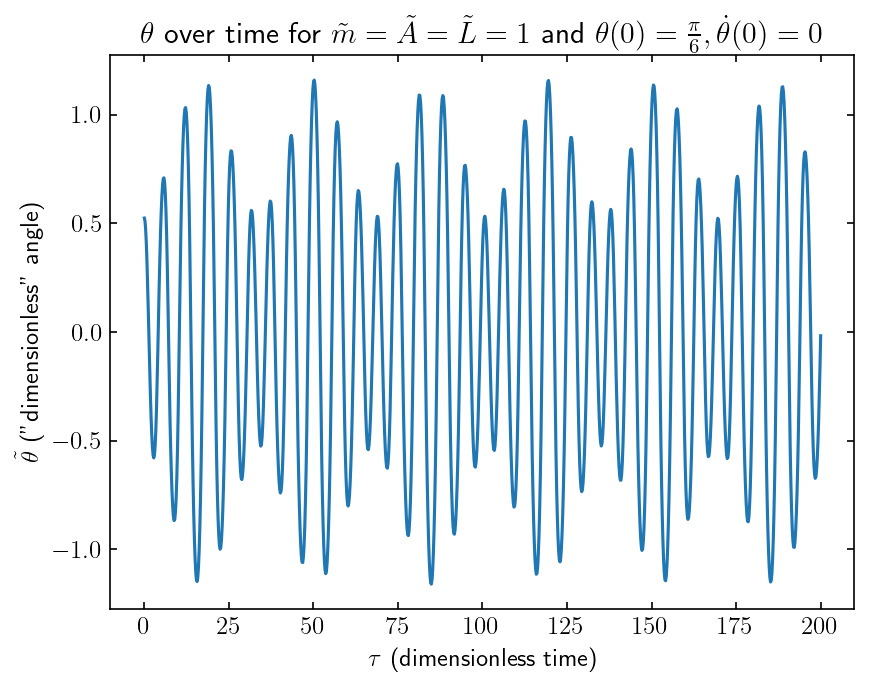

In [4]:
tau_max = 200

time = np.linspace(0, tau_max, 1000)
solution = solve_ivp(ELE, (0, tau_max), (0, np.pi/6), t_eval = time, max_step=1e-2)
dthetas, thetas = solution.y

plt.plot(time, thetas)
plt.xlabel(r'$\tau$ (dimensionless time)')
plt.ylabel(r'$\tilde\theta$ ("dimensionless" angle)')
plt.title(r"$\theta$ over time for $\tilde{m} = \tilde{A} = \tilde{L} = 1$ and $\theta(0) = \frac{\pi}{6}, \dot\theta(0) = 0$")
plt.show()